# Notebook d'analyse - Projet AAA UOI Games

In [1]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pyxlsb


[notice] A new release of pip is available: 23.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Data All Video Game

In [4]:
All_VideoGame = pd.read_excel('All_publish_VideoGame_2022.xlsb', engine='pyxlsb')

In [5]:
All_VideoGame.head()

,id,slug,name,metacritic,released,Annee,tba,rating,rating_top,playtime,...,Apple II,NES,Dreamcast,PlayStation 5,Xbox Series S/X,Commodore / Amiga,Atari 26,Atari ST,Atari 78,SEGA Saturn
0,1,dgeneration-hd,D/Generation HD,NaN,42300,2015,False,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,g-prime,G Prime Into The Rain,NaN,42375,2016,False,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,land-sliders,Land Sliders,NaN,42271,2015,False,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000,pixel-gear,Pixel Gear,NaN,42663,2016,False,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10000,gods-and-idols,Gods and Idols,NaN,42716,2016,False,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
All_VideoGame = All_VideoGame.loc[:, : "platforms"]

In [7]:
All_VideoGame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440896 entries, 0 to 440895
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    440896 non-null  int64  
 1   slug                  440894 non-null  object 
 2   name                  440894 non-null  object 
 3   metacritic            4627 non-null    float64
 4   released              440896 non-null  int64  
 5   Annee                 440896 non-null  int64  
 6   tba                   440896 non-null  bool   
 7   rating                440833 non-null  float64
 8   rating_top            440833 non-null  float64
 9   playtime              440833 non-null  float64
 10  achievements_count    440833 non-null  float64
 11  ratings_count         440833 non-null  float64
 12  suggestions_count     440833 non-null  float64
 13  game_series_count     440833 non-null  float64
 14  reviews_count         440833 non-null  float64
 15  

In [8]:
# Conversion des dates
All_VideoGame["released"] = pd.to_datetime(All_VideoGame["released"], errors="coerce")

# Nettoyage Metacritic
All_VideoGame["metacritic"] = pd.to_numeric(All_VideoGame["metacritic"], errors="coerce")

# Nettoyage Annee
All_VideoGame["Annee"] = All_VideoGame["Annee"].astype(str).str.replace(",", ".").astype(float).astype(int)

# Conversion colonnes numériques
cols_num = ["rating", "rating_top", "playtime", "achievements_count",
            "ratings_count", "suggestions_count", "reviews_count",
            "added_status_yet", "added_status_owned", "added_status_beaten",
            "added_status_toplay", "added_status_dropped", "added_status_playing"]

for c in cols_num:
    All_VideoGame[c] = pd.to_numeric(All_VideoGame[c], errors="coerce")

# Nettoyage colonnes listes séparées par || 
split_cols = ["developers", "genres", "publishers", "platforms"]

for c in split_cols:
    All_VideoGame[c] = All_VideoGame[c].fillna("").apply(lambda x: x.split("||") if isinstance(x, str) else [])

In [9]:
All_VideoGame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440896 entries, 0 to 440895
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    440896 non-null  int64         
 1   slug                  440894 non-null  object        
 2   name                  440894 non-null  object        
 3   metacritic            4627 non-null    float64       
 4   released              440896 non-null  datetime64[ns]
 5   Annee                 440896 non-null  int32         
 6   tba                   440896 non-null  bool          
 7   rating                440833 non-null  float64       
 8   rating_top            440833 non-null  float64       
 9   playtime              440833 non-null  float64       
 10  achievements_count    440833 non-null  float64       
 11  ratings_count         440833 non-null  float64       
 12  suggestions_count     440833 non-null  float64       
 13 

In [10]:
All_VideoGame[All_VideoGame.duplicated(subset=['id'], keep=False)]

,id,slug,name,metacritic,released,Annee,tba,rating,rating_top,playtime,...,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing,platforms


In [11]:
# Remplacement des valeurs manquantes
All_VideoGame = All_VideoGame.fillna({
    "metacritic": 0,
    "rating": 0,
    "reviews_count": 0
})


In [12]:
# KPI 1 : Score global (moyenne pondérée)
All_VideoGame["score_global"] = (
    All_VideoGame["rating"] * 0.4 +
    All_VideoGame["rating_top"] * 0.2 +
    All_VideoGame["metacritic"] * 0.4
)

In [13]:
# KPI 2 : Popularité (volume d'interactions)
All_VideoGame["popularite"] = (
    All_VideoGame["ratings_count"] +
    All_VideoGame["reviews_count"] +
    All_VideoGame["suggestions_count"]
)

In [14]:
# KPI 3 : Engagement (temps de jeu + statut owned)
All_VideoGame["engagement"] = All_VideoGame["playtime"] + All_VideoGame["added_status_owned"]


In [15]:
# KPI 4 : Plateforme principale
All_VideoGame["main_platform"] = All_VideoGame["platforms"].apply(lambda x: x[0] if len(x) > 0 else "Unknown")

In [16]:
# Aperçu KPI
display(All_VideoGame[["name", "score_global", "popularite", "engagement", "main_platform"]].head())


,name,score_global,popularite,engagement,main_platform
0,D/Generation HD,0.0,298.0,89.0,PC
1,G Prime Into The Rain,0.0,395.0,42.0,macOS
2,Land Sliders,0.0,87.0,2.0,iOS
3,Pixel Gear,0.0,455.0,1.0,PC
4,Gods and Idols,0.2,272.0,80.0,PC


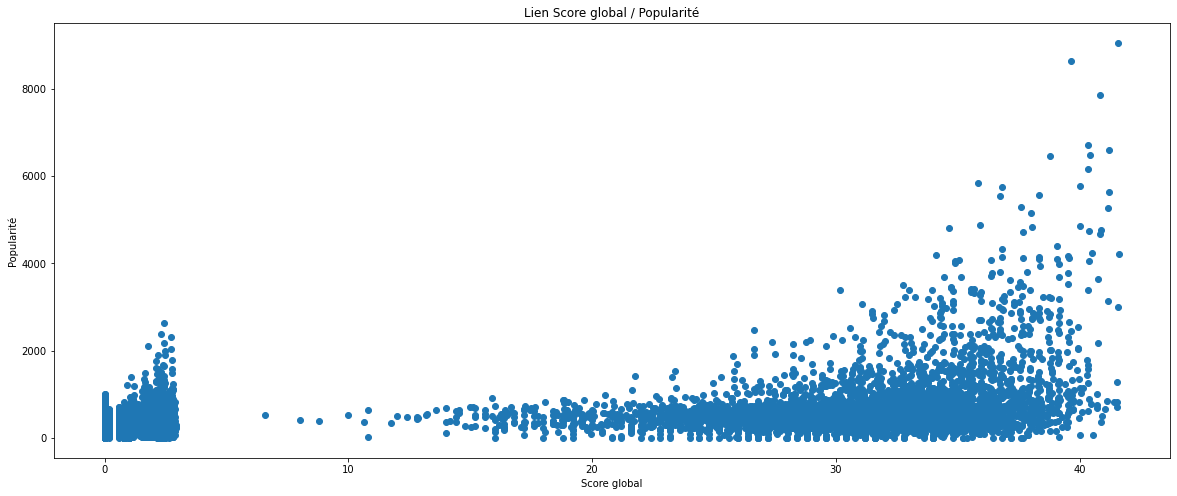

In [17]:
#  Score global vs popularité
plt.figure(figsize=(20,8))
plt.scatter(All_VideoGame["score_global"], All_VideoGame["popularite"])
plt.xlabel("Score global")
plt.ylabel("Popularité")
plt.title("Lien Score global / Popularité")
plt.show()

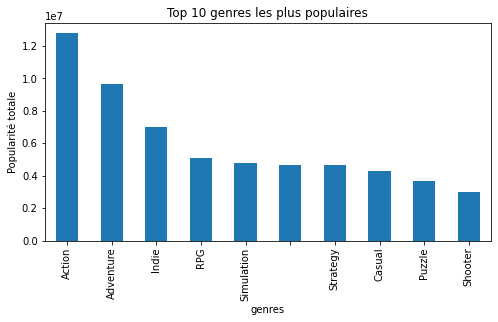

In [18]:
#  Top 10 genres les plus populaires
genres_exploded = All_VideoGame.explode("genres")
pop_genres = genres_exploded.groupby("genres")["popularite"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
pop_genres.plot(kind="bar")
plt.title("Top 10 genres les plus populaires")
plt.ylabel("Popularité totale")
plt.show()

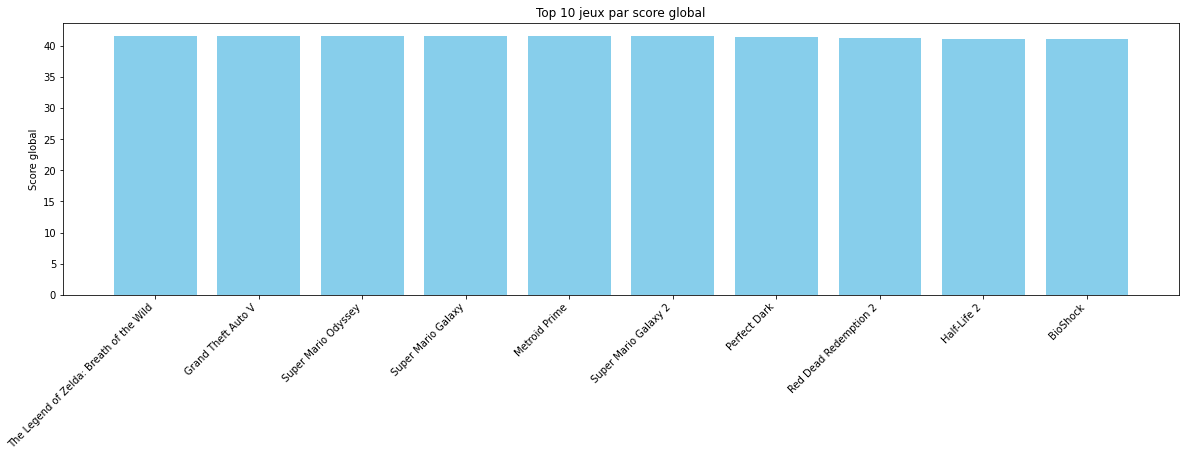

In [19]:
# Top 10 jeux par score global
top_scores = All_VideoGame.sort_values("score_global", ascending=False).head(10)

plt.figure(figsize=(20,5))
plt.bar(top_scores["name"], top_scores["score_global"], color='skyblue')
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 jeux par score global")
plt.ylabel("Score global")
plt.show()

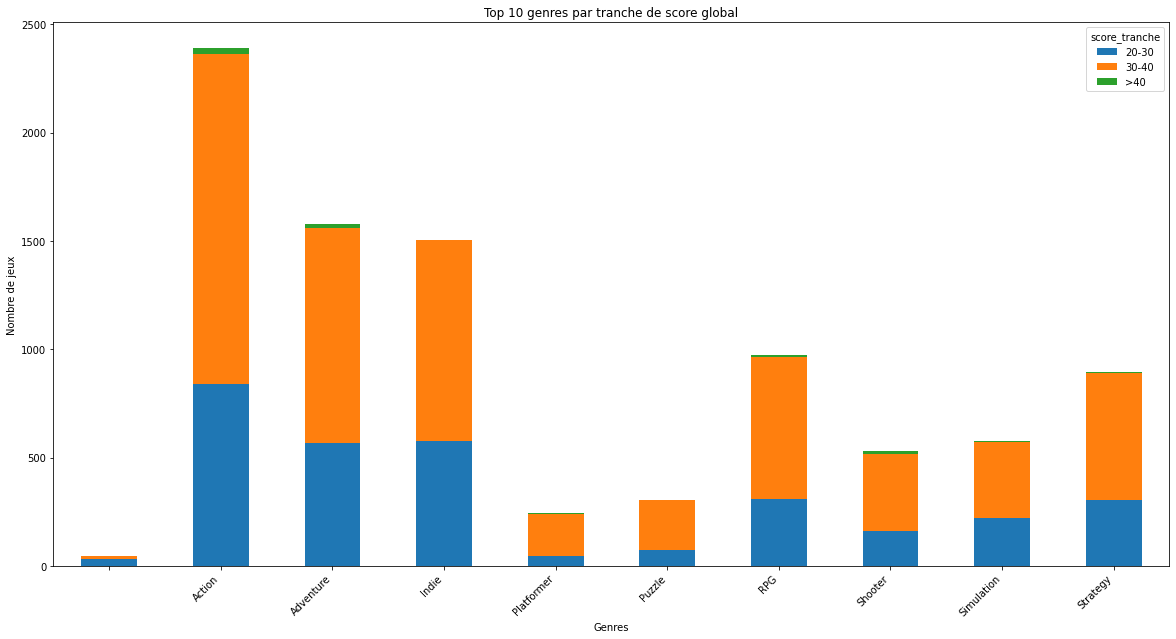

In [20]:
# Définir les tranches demandées
bins = [20, 30, 40, 100]
labels = ['20-30', '30-40', '>40']
All_VideoGame['score_tranche'] = pd.cut(All_VideoGame['score_global'], bins=bins, labels=labels, right=False)

# Exploser les genres
genres_exploded = All_VideoGame.explode("genres")

# Top 10 genres par nombre de jeux
top_genres = genres_exploded['genres'].value_counts().head(10).index

# Filtrer uniquement le top 10
top_genres_df = genres_exploded[genres_exploded['genres'].isin(top_genres)]

# Compter les jeux par genre et tranche de score
genre_score_counts = top_genres_df.groupby(['genres', 'score_tranche']).size().unstack(fill_value=0)

# Graphique
genre_score_counts.plot(kind='bar', figsize=(20,10), stacked=True)
plt.title("Top 10 genres par tranche de score global")
plt.ylabel("Nombre de jeux")
plt.xlabel("Genres")
plt.xticks(rotation=45, ha="right")
plt.show()

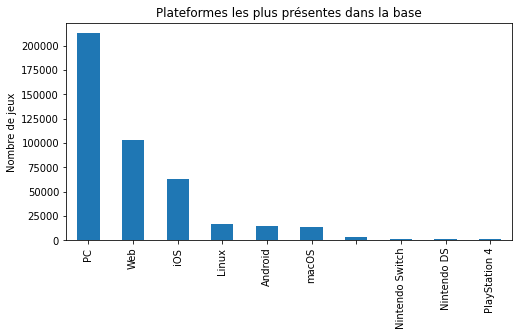

In [21]:
#  Plateformes dominantes
plt.figure(figsize=(8,4))
All_VideoGame["main_platform"].value_counts().head(10).plot(kind="bar")
plt.title("Plateformes les plus présentes dans la base")
plt.ylabel("Nombre de jeux")
plt.show()

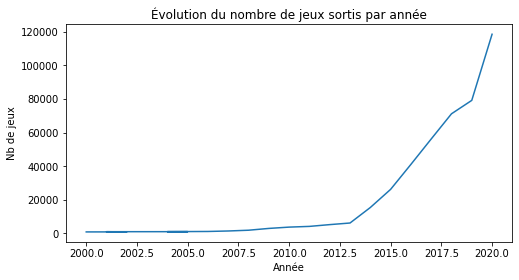

In [22]:
#  Évolution des sorties de jeux par année
All_VideoGame["Annee"] = pd.to_numeric(All_VideoGame["Annee"], errors="coerce")
plt.figure(figsize=(8,4))
All_VideoGame["Annee"].value_counts().plot(kind="line")
plt.title("Évolution du nombre de jeux sortis par année")
plt.xlabel("Année")
plt.ylabel("Nb de jeux")
plt.show()

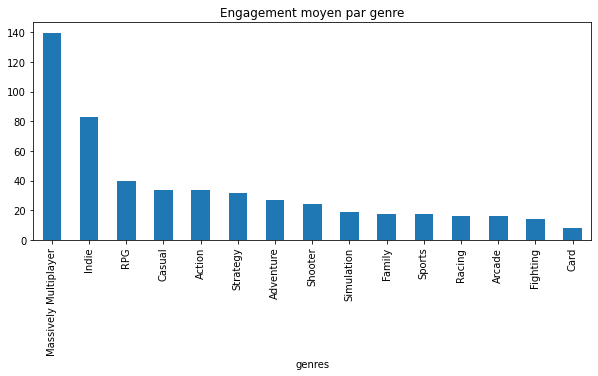

In [23]:
genres_eng = genres_exploded.groupby("genres")["engagement"].mean().sort_values(ascending=False).head(15)
genres_eng.plot(kind="bar", figsize=(10,4))
plt.title("Engagement moyen par genre")
plt.show()

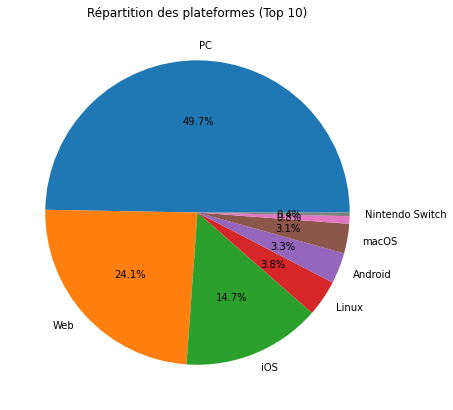

In [24]:
top10 = All_VideoGame["main_platform"].value_counts().head(8)
top10.plot(kind="pie", figsize=(7,7), autopct='%1.1f%%')
plt.title("Répartition des plateformes (Top 10)")
plt.ylabel("")
plt.show()

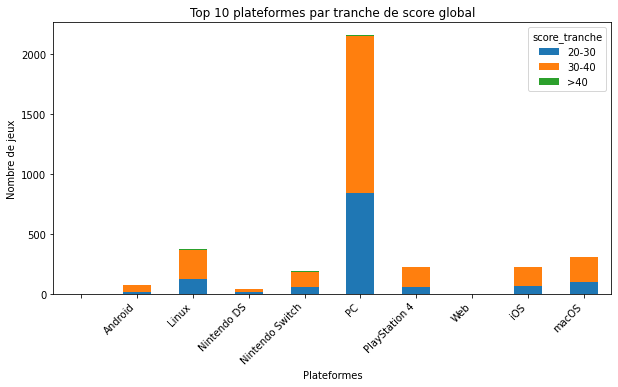

In [25]:
# Définir les tranches de score
bins = [20, 30, 40, 100]
labels = ['20-30', '30-40', '>40']
All_VideoGame['score_tranche'] = pd.cut(All_VideoGame['score_global'], bins=bins, labels=labels, right=False)

# Top 10 plateformes par nombre de jeux
top_platforms = All_VideoGame['main_platform'].value_counts().head(10).index

# Filtrer les plateformes
platform_df = All_VideoGame[All_VideoGame['main_platform'].isin(top_platforms)]

# Compter par plateforme et tranche de score
platform_score_counts = platform_df.groupby(['main_platform', 'score_tranche']).size().unstack(fill_value=0)

# Graphique
platform_score_counts.plot(kind='bar', figsize=(10,5), stacked=True)
plt.title("Top 10 plateformes par tranche de score global")
plt.ylabel("Nombre de jeux")
plt.xlabel("Plateformes")
plt.xticks(rotation=45, ha="right")
plt.show()

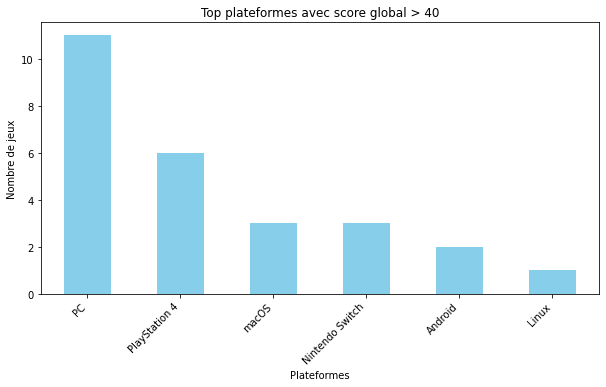

In [26]:
# Filtrer uniquement la tranche '>40'
high_score_df = platform_df[platform_df['score_tranche'] == '>40']

# Compter par plateforme
high_score_counts = high_score_df['main_platform'].value_counts().head(10)

# Graphique
plt.figure(figsize=(10,5))
high_score_counts.plot(kind='bar', color='skyblue')
plt.title("Top plateformes avec score global > 40")
plt.ylabel("Nombre de jeux")
plt.xlabel("Plateformes")
plt.xticks(rotation=45, ha="right")
plt.show()

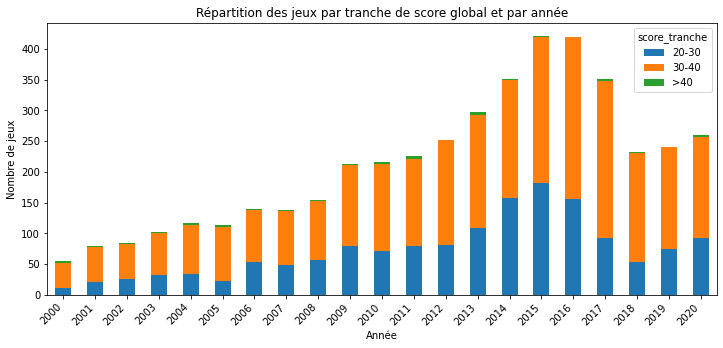

In [27]:
# Définir les tranches de score
bins = [20, 30, 40, 100]
labels = ['20-30', '30-40', '>40']
All_VideoGame['score_tranche'] = pd.cut(All_VideoGame['score_global'], bins=bins, labels=labels, right=False)

# Convertir l'année en numérique
All_VideoGame["Annee"] = pd.to_numeric(All_VideoGame["Annee"], errors="coerce")

# Grouper par année et tranche de score
year_score_counts = All_VideoGame.groupby(['Annee', 'score_tranche']).size().unstack(fill_value=0)

# Graphique empilé
year_score_counts.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Répartition des jeux par tranche de score global et par année")
plt.ylabel("Nombre de jeux")
plt.xlabel("Année")
plt.xticks(rotation=45, ha="right")
plt.show()

In [28]:
# df.to_csv("jeux_video_clean_kpi.csv", index=False)
print("Fichier exporté : jeux_video_clean_kpi.csv")

Fichier exporté : jeux_video_clean_kpi.csv


## 2) Data Video Game Sales

In [29]:
VideoGame_Sales = pd.read_excel('VideoGame_Sales_1980-2016+(1).xlsb', engine='pyxlsb', sheet_name='vgsales')

In [30]:
VideoGame_Sales.head()

,Rank,Name,Platform,Year,Genre,Publisher,Constructeur,Portable,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,Nintendo,Non,41.4900,27.8592,3.6569,8.2908,81.2969
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,Nintendo,Non,29.9524,3.4726,6.6738,0.8085,40.9073
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,Nintendo,Non,15.2160,12.4936,3.7900,3.3762,34.8758
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,Nintendo,Non,15.7500,11.0100,3.1816,3.0784,33.0200
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,Nintendo,Oui,11.2700,9.0678,9.8112,0.9900,31.1390


In [31]:
# Data Structure
VideoGame_Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16545 entries, 0 to 16544
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16545 non-null  int64  
 1   Name          16545 non-null  object 
 2   Platform      16545 non-null  object 
 3   Year          16274 non-null  float64
 4   Genre         16545 non-null  object 
 5   Publisher     16487 non-null  object 
 6   Constructeur  16545 non-null  object 
 7   Portable      16545 non-null  object 
 8   NA_Sales      16545 non-null  float64
 9   EU_Sales      16545 non-null  float64
 10  JP_Sales      16545 non-null  float64
 11  Other_Sales   16545 non-null  float64
 12  Global_Sales  16545 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 1.6+ MB


In [32]:
# Check for missing values
missing_values = VideoGame_Sales.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
Constructeur      0
Portable          0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [33]:
VideoGame_Sales = VideoGame_Sales.dropna(subset = ['Year', 'Publisher'])
VideoGame_Sales.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
Constructeur    0
Portable        0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

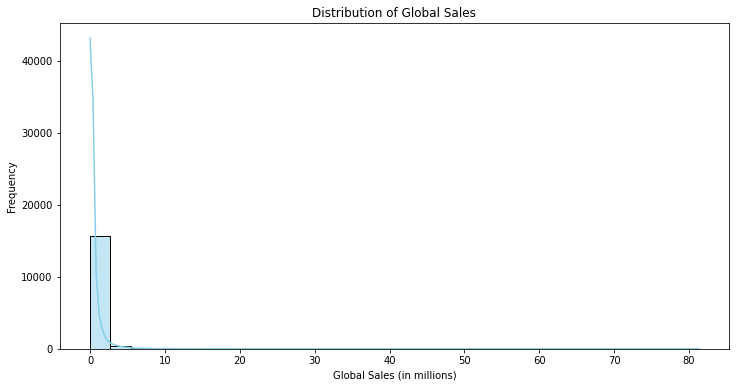

In [34]:
# Global Sales Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(VideoGame_Sales['Global_Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.show()

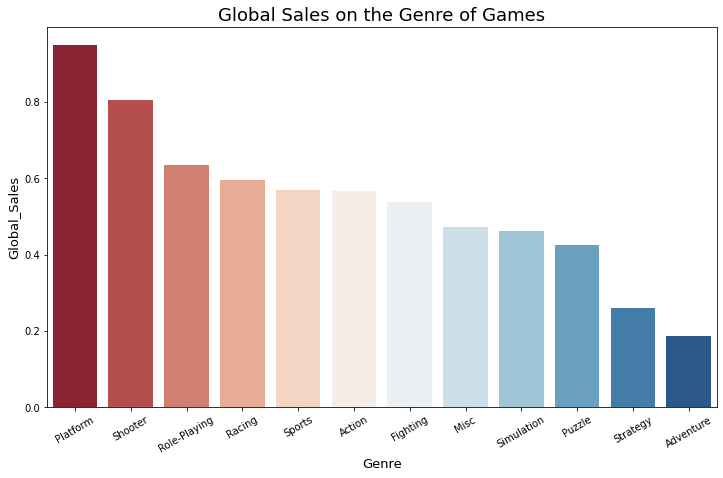

In [35]:
#Average Global Sales on the Genre of Games
genre=list(VideoGame_Sales.Genre.unique())
global_sales=[]
for i in genre:
    val=VideoGame_Sales[VideoGame_Sales.Genre==i]
    x=val.Global_Sales.mean()
    global_sales.append(x)
    
d1 = pd.DataFrame({"Genre":genre,"Global_Sales":global_sales})
d1.sort_values("Global_Sales",ascending=False,inplace=True)

#visualization
plt.figure(figsize=(12,7))
sns.barplot(x="Genre", y="Global_Sales", data=d1, palette="RdBu")
#sns.despine(left = True, right = True)
plt.xticks(rotation= 30)
plt.xlabel("Genre", fontsize=13, color="black")
plt.ylabel("Global_Sales", fontsize=13, color="black")
plt.title("Global Sales on the Genre of Games", fontsize=18, color="black")
plt.show()

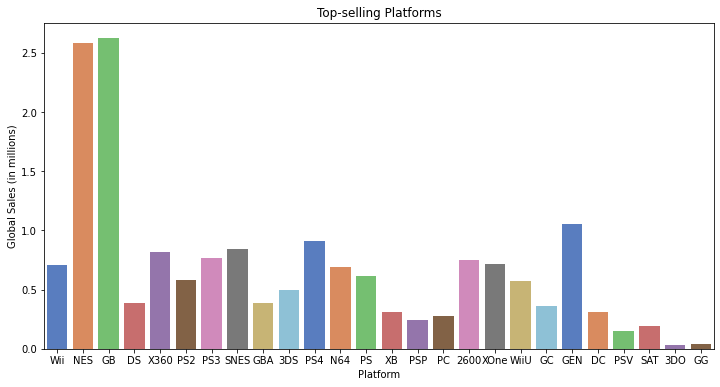

In [36]:
# Top-selling Platforms
plt.figure(figsize=(12, 6))
sns.barplot(x='Platform', y='Global_Sales', data=VideoGame_Sales, palette='muted', errorbar=None)
plt.title('Top-selling Platforms')
plt.xlabel('Platform')
plt.ylabel('Global Sales (in millions)')
plt.show()

## 3) Data Vente Console

In [37]:
Vente_Console = pd.read_excel('Vente+de+console_2022.xlsx')

In [38]:
Vente_Console.head()

,Console,Constructeur,Date de Sortie,Vente (en million)
0,PlayStation 2,Sony,2000,158.0000
1,Nintendo DS,Nintendo,2004,157.1004
2,Switch,Nintendo,2017,126.8762
3,Game Boy (avec Color),Nintendo,1989,118.6900
4,PlayStation 4,Sony,2013,115.8300


In [39]:
Vente_Console.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Console             20 non-null     object 
 1   Constructeur        20 non-null     object 
 2   Date de Sortie      20 non-null     int64  
 3   Vente (en million)  20 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 768.0+ bytes


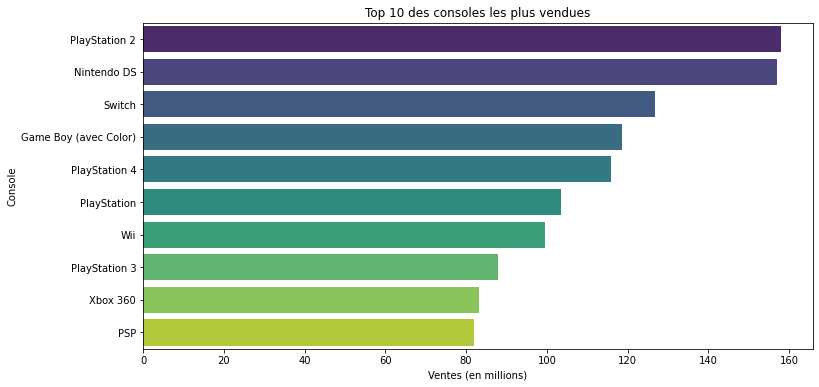

In [40]:
# ------------------------------------------
# 2. Top 10 consoles les plus vendues
# ------------------------------------------
plt.figure(figsize=(12,6))
sns.barplot(
    data=Vente_Console.sort_values("Vente (en million)", ascending=False).head(10),
    x="Vente (en million)",
    y="Console",
    errorbar=None,
    palette="viridis"
)
plt.title("Top 10 des consoles les plus vendues")
plt.xlabel("Ventes (en millions)")
plt.ylabel("Console")
plt.show()

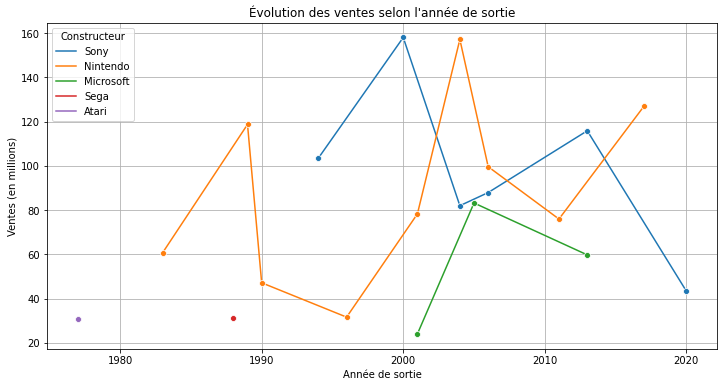

In [41]:
# ------------------------------------------
# 5. Évolution chronologique des consoles
# ------------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(data=Vente_Console, x="Date de Sortie", y="Vente (en million)", hue="Constructeur", marker="o")
plt.title("Évolution des ventes selon l'année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Ventes (en millions)")
plt.grid(True)
plt.show()

## 4) Data Steamspy

In [42]:
Steam_Games = pd.read_csv('SteamSpy - All the data and stats_Steam games.csv' , sep=';')

In [43]:
Steam_Games.head()

,#,Game,Release date,Price,Score rank(Userscore / Metascore),Owners
0,1,INAZUMA ELEVEN: Victory Road,"Nov 13, 2025","69,99 $",N/A (N/A),"0 .. 20,000"
1,2,Voidtrain,"Nov 7, 2025","19,49 $",N/A (N/A),"200,000 .. 500,000"
2,3,Whiskerwood,"Nov 6, 2025","23,99 $",N/A (N/A),"0 .. 20,000"
3,4,Escape the Backrooms,"Oct 23, 2025","9,99 $",N/A (N/A),"2,000,000 .. 5,000,000"
4,5,Farthest Frontier,"Oct 23, 2025","34,99 $",N/A (N/A/83%),"1,000,000 .. 2,000,000"


In [44]:

# 1. Nettoyer le prix : enlever $ et espaces, remplacer virgule par point
Steam_Games['Price'] = Steam_Games['Price'].astype(str).str.replace('$', '', regex=False)\
                                                  .str.replace(' ', '', regex=False)\
                                                  .str.replace(',', '.', regex=False)
Steam_Games['Price'] = pd.to_numeric(Steam_Games['Price'], errors='coerce')

# 2. Forcer la colonne score en string
Steam_Games['Score rank(Userscore / Metascore)'] = Steam_Games['Score rank(Userscore / Metascore)'].astype(str)

# 3. Séparer Userscore et Metascore
Steam_Games[['Userscore', 'Metascore']] = Steam_Games['Score rank(Userscore / Metascore)']\
    .str.extract(r'(\d+\.?\d*|N/A)\s*/\s*(\d+\.?\d*|N/A)')

# Convertir en float et remplacer N/A par NaN
Steam_Games['Userscore'] = pd.to_numeric(Steam_Games['Userscore'], errors='coerce')
Steam_Games['Metascore'] = pd.to_numeric(Steam_Games['Metascore'], errors='coerce')

# 4. Nettoyer Owners : moyenne de la plage
def owners_avg(x):
    if pd.isna(x):
        return np.nan
    parts = x.replace(' ', '').split('..')
    if len(parts) == 2:
        try:
            return (int(parts[0]) + int(parts[1])) / 2
        except:
            return np.nan
    return np.nan

Steam_Games['Owners_avg'] = Steam_Games['Owners'].apply(owners_avg)

# 5. Convertir la date de sortie en datetime
Steam_Games['Release date'] = pd.to_datetime(Steam_Games['Release date'], errors='coerce')

In [45]:
# Vérifier le résultat
Steam_Games.head()

,#,Game,Release date,Price,Score rank(Userscore / Metascore),Owners,Userscore,Metascore,Owners_avg
0,1,INAZUMA ELEVEN: Victory Road,2025-11-13,69.99,N/A (N/A),"0 .. 20,000",NaN,NaN,NaN
1,2,Voidtrain,2025-11-07,19.49,N/A (N/A),"200,000 .. 500,000",NaN,NaN,NaN
2,3,Whiskerwood,2025-11-06,23.99,N/A (N/A),"0 .. 20,000",NaN,NaN,NaN
3,4,Escape the Backrooms,2025-10-23,9.99,N/A (N/A),"2,000,000 .. 5,000,000",NaN,NaN,NaN
4,5,Farthest Frontier,2025-10-23,34.99,N/A (N/A/83%),"1,000,000 .. 2,000,000",NaN,83.0,NaN


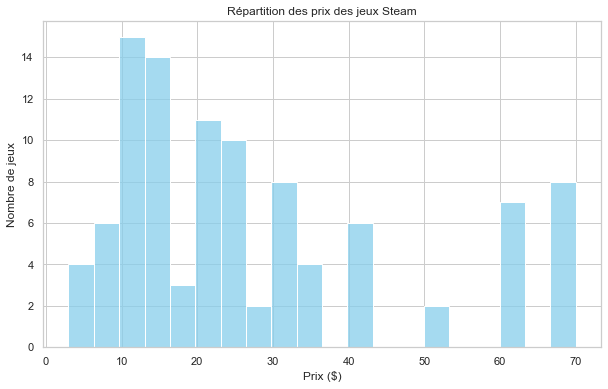

In [46]:

# --- Paramètres graphiques ---
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# --- 1. Répartition des prix ---
plt.figure()
sns.histplot(Steam_Games['Price'].dropna(), bins=20, kde=False, color='skyblue')
plt.title("Répartition des prix des jeux Steam")
plt.xlabel("Prix ($)")
plt.ylabel("Nombre de jeux")
plt.show()

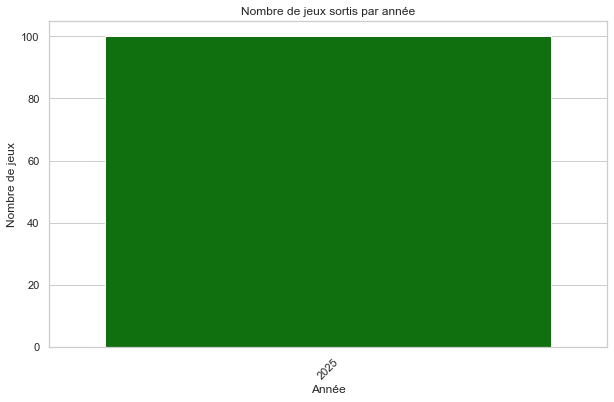

In [47]:

# --- 5. Evolution du nombre de jeux par année ---
Steam_Games['Year'] = Steam_Games['Release date'].dt.year
year_count = Steam_Games['Year'].value_counts().sort_index()

plt.figure()
sns.barplot(x=year_count.index, y=year_count.values, color='green')
plt.title("Nombre de jeux sortis par année")
plt.xlabel("Année")
plt.ylabel("Nombre de jeux")
plt.xticks(rotation=45)
plt.show()

In [48]:
# --- 6. Statistiques résumées ---
print("=== Statistiques résumées ===")
print("Prix moyen:", Steam_Games['Price'].mean())
print("Prix médian:", Steam_Games['Price'].median())
print("Userscore moyen:", Steam_Games['Userscore'].mean())
print("Metascore moyen:", Steam_Games['Metascore'].mean())
print("Nombre moyen de propriétaires:", Steam_Games['Owners_avg'].mean())
print("Top 5 jeux les plus populaires:")
print(Steam_Games[['Game', 'Owners_avg']].sort_values(by='Owners_avg', ascending=False).head())

=== Statistiques résumées ===
Prix moyen: 27.151299999999992
Prix médian: 19.99
Userscore moyen: nan
Metascore moyen: 84.46153846153847
Nombre moyen de propriétaires: nan
Top 5 jeux les plus populaires:
                           Game  Owners_avg
0  INAZUMA ELEVEN: Victory Road         NaN
1                     Voidtrain         NaN
2                   Whiskerwood         NaN
3          Escape the Backrooms         NaN
4             Farthest Frontier         NaN


## 5) Prévisions Global SALES

C:\Users\Noura\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Noura\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Prévisions Global Sales (en millions) :
2017 : 100.89
2018 : 67.42
2019 : 44.95
2020 : 29.85
2021 : 19.72
2022 : 12.91
2023 : 8.34
2024 : 5.27
2025 : 3.21
2026 : 1.83


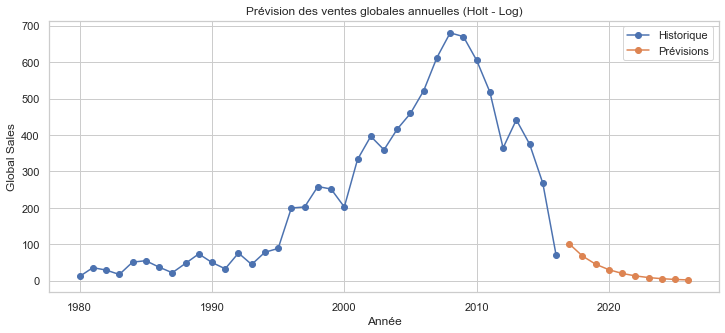

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ----------------------------------------------------------
# 1. PREPARATION DES DONNEES
# ----------------------------------------------------------
df = VideoGame_Sales.copy()

df = df[['Year', 'Global_Sales']].dropna()
df['Year'] = df['Year'].astype(int)

# Années valides
df = df[(df['Year'] >= 1980) & (df['Year'] <= 2016)]

# ----------------------------------------------------------
# 2. AGREGER PAR ANNEE
# ----------------------------------------------------------
annual = (
    df.groupby('Year')['Global_Sales']
    .sum()
    .sort_index()
)

ts = annual

if ts.empty:
    raise ValueError("La série temporelle est vide")

# ----------------------------------------------------------
# 3. TRANSFORMATION LOG (evite les valeurs negatives)
# ----------------------------------------------------------
ts_log = np.log(ts + 1)

# ----------------------------------------------------------
# 4. MODELE HOLT
# ----------------------------------------------------------
model = ExponentialSmoothing(
    ts_log,
    trend='add',
    seasonal=None
)

fit = model.fit(optimized=True)

# ----------------------------------------------------------
# 5. PREVISIONS JUSQU'A 2026
# ----------------------------------------------------------
last_year = ts.index.max()
target_year = 2026

n_forecast = target_year - last_year

forecast_log = fit.forecast(n_forecast)

# Retour a l'echelle originale
forecast = np.exp(forecast_log) - 1
forecast[forecast < 0] = 0

years_forecast = range(last_year + 1, target_year + 1)

print("Prévisions Global Sales (en millions) :")
for y, v in zip(years_forecast, forecast):
    print(y, ":", round(v, 2))

# ----------------------------------------------------------
# 6. GRAPHIQUE
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label="Historique", marker='o')
plt.plot(years_forecast, forecast, label="Prévisions", marker='o')
plt.title("Prévision des ventes globales annuelles (Holt - Log)")
plt.xlabel("Année")
plt.ylabel("Global Sales")
plt.legend()
plt.grid(True)
plt.show()
